# 10 — Long Training Selected Public Model

Notebook 09 screened combined public-data augmentation recipes at 5 epochs. This notebook takes the single Notebook 09 selected recipe, retrains it longer on public data only, selects the best public-validation epoch, and evaluates that best-validation model once on the held-out public test split.

This notebook is the second phase of the 09–11 generalization-optimization workflow:

1. **Notebook 09** screened combined public augmentation recipes using public validation performance.
2. **Notebook 10** retrains the selected Notebook 09 recipe longer on public data only.
3. **Notebook 11** evaluates the Notebook 10 model on the clinical PSD-derived dataset and compares it to Notebook 08.

Clinical data are not used in this notebook.

In [1]:
# 10.01 — Imports

from __future__ import annotations

import copy
import json
import math
import os
import platform
import sys
import time
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display


In [2]:
# 10.02 — Project root and source path setup

def find_project_root(start: Path | None = None) -> Path:
    """Find the repository root by walking upward to the .git directory."""
    current = Path.cwd() if start is None else Path(start).resolve()

    for candidate in [current, *current.parents]:
        if (candidate / ".git").exists():
            return candidate

    raise FileNotFoundError("Could not find project root containing .git.")


PROJECT_ROOT = find_project_root()
SRC_DIR = PROJECT_ROOT / "src"

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

os.chdir(PROJECT_ROOT)

print(f"Project root: {PROJECT_ROOT.name}")
print(f"Source directory available: {SRC_DIR.exists()}")
print(f"Python executable: {sys.executable}")
print(f"Python version: {platform.python_version()}")


Project root: Automated-Glaucoma-Screening-Using-AI-Enhanced-Ophthalmoscopy
Source directory available: True
Python executable: <HOME>/.conda/envs/glaucoma-capstone/bin/python
Python version: 3.11.15


In [3]:
# 10.03 — Paths and output directories

MANIFEST_PATH = PROJECT_ROOT / "data/processed/manifests/combined_segmentation_manifest_with_splits.csv"

REPORTS_DIR = PROJECT_ROOT / "reports"
TRAINING_REPORT_DIR = REPORTS_DIR / "training"
DATA_AUDIT_REPORT_DIR = REPORTS_DIR / "data_audit"
PRIVATE_CHECKPOINT_DIR = PROJECT_ROOT / "data/interim/private_model_checkpoints/notebook_10"

TRAINING_REPORT_DIR.mkdir(parents=True, exist_ok=True)
DATA_AUDIT_REPORT_DIR.mkdir(parents=True, exist_ok=True)
PRIVATE_CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

NOTEBOOK_07_SUMMARY_PATH = TRAINING_REPORT_DIR / "final_model_selection_summary.csv"
NOTEBOOK_09_SUMMARY_PATH = TRAINING_REPORT_DIR / "combined_public_augmentation_summary.csv"

PLAN_PATH = TRAINING_REPORT_DIR / "long_training_selected_public_plan.csv"
HISTORY_PATH = TRAINING_REPORT_DIR / "long_training_selected_public_history.csv"
METADATA_PATH = TRAINING_REPORT_DIR / "long_training_selected_public_metadata.csv"
VALIDATION_SUMMARY_PATH = TRAINING_REPORT_DIR / "long_training_selected_public_validation_summary.csv"
TEST_SUMMARY_PATH = TRAINING_REPORT_DIR / "long_training_selected_public_test_summary.csv"
SUMMARY_PATH = TRAINING_REPORT_DIR / "long_training_selected_public_summary.csv"
DATASET_SUMMARY_PATH = DATA_AUDIT_REPORT_DIR / "long_training_selected_public_dataset_summary.csv"

PRIVATE_BEST_CHECKPOINT_PATH = (
    PRIVATE_CHECKPOINT_DIR / "long_training_selected_public_best_state_private.pt"
)
PRIVATE_LATEST_CHECKPOINT_PATH = (
    PRIVATE_CHECKPOINT_DIR / "long_training_selected_public_latest_state_private.pt"
)

paths = pd.DataFrame(
    [
        {"artifact": "combined public manifest", "path": MANIFEST_PATH, "exists": MANIFEST_PATH.exists()},
        {"artifact": "Notebook 07 final summary", "path": NOTEBOOK_07_SUMMARY_PATH, "exists": NOTEBOOK_07_SUMMARY_PATH.exists()},
        {"artifact": "Notebook 09 summary", "path": NOTEBOOK_09_SUMMARY_PATH, "exists": NOTEBOOK_09_SUMMARY_PATH.exists()},
        {"artifact": "Notebook 10 plan output", "path": PLAN_PATH, "exists": PLAN_PATH.exists()},
        {"artifact": "Notebook 10 history output", "path": HISTORY_PATH, "exists": HISTORY_PATH.exists()},
        {"artifact": "Notebook 10 validation output", "path": VALIDATION_SUMMARY_PATH, "exists": VALIDATION_SUMMARY_PATH.exists()},
        {"artifact": "Notebook 10 test output", "path": TEST_SUMMARY_PATH, "exists": TEST_SUMMARY_PATH.exists()},
        {"artifact": "Notebook 10 private best checkpoint", "path": PRIVATE_BEST_CHECKPOINT_PATH, "exists": PRIVATE_BEST_CHECKPOINT_PATH.exists()},
    ]
)

display(paths.assign(path=paths["path"].map(lambda path: str(Path(path).relative_to(PROJECT_ROOT)))))

missing_required = paths.loc[
    paths["artifact"].isin(
        ["combined public manifest", "Notebook 07 final summary", "Notebook 09 summary"]
    )
    & ~paths["exists"],
    "artifact",
].tolist()

if missing_required:
    raise FileNotFoundError(f"Missing required Notebook 10 inputs: {missing_required}")


,artifact,path,exists
0,combined public manifest,data/processed/manifests/combined_segmentation...,True
1,Notebook 07 final summary,reports/training/final_model_selection_summary...,True
2,Notebook 09 summary,reports/training/combined_public_augmentation_...,True
3,Notebook 10 plan output,reports/training/long_training_selected_public...,False
4,Notebook 10 history output,reports/training/long_training_selected_public...,False
5,Notebook 10 validation output,reports/training/long_training_selected_public...,False
6,Notebook 10 test output,reports/training/long_training_selected_public...,False
7,Notebook 10 private best checkpoint,data/interim/private_model_checkpoints/noteboo...,False


In [4]:
# 10.04 — Core project module import check

from glaucoma_segmentation.augmentation import (
    build_online_augmentation_preset,
    build_virtual_synthetic_expansion_dataset,
    combined_online_augmentation_components,
    summarize_virtual_synthetic_expansion,
)
from glaucoma_segmentation.data.dataloaders import (
    make_segmentation_dataloader,
    make_segmentation_datasets,
)
from glaucoma_segmentation.nets.losses import DiceCELoss
from glaucoma_segmentation.nets.model_factory import build_model
from glaucoma_segmentation.training.train_loop import (
    extract_images_and_masks,
    model_forward,
    run_one_epoch_with_progress,
)
from glaucoma_segmentation.utils.device import describe_device, device_summary_dict, get_device
from glaucoma_segmentation.utils.seed import seed_everything

print("Core project imports: OK")


<HOME>/.conda/envs/glaucoma-capstone/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Core project imports: OK


In [5]:
# 10.05 — Long-training configuration

SEED = 42
IMAGE_SIZE = (256, 256)
BATCH_SIZE = 8
EPOCHS = 25
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4
ENCODER_WEIGHTS = None
NUM_CLASSES = 3
PIN_MEMORY = torch.cuda.is_available()

cpu_count = os.cpu_count() or 2
NUM_WORKERS = min(4, max(1, cpu_count - 1))

PRIMARY_METRIC = "val_mean_foreground_dice"
MEANINGFUL_DICE_DELTA = 0.005

# Set True only when deliberately replacing Notebook 10 outputs/checkpoints.
FORCE_RERUN = False

seed_config = seed_everything(SEED, deterministic=False)
DEVICE = get_device()
DEVICE_INFO = device_summary_dict(DEVICE)

config = {
    "seed": SEED,
    "image_size": IMAGE_SIZE,
    "batch_size": BATCH_SIZE,
    "epochs": EPOCHS,
    "learning_rate": LEARNING_RATE,
    "weight_decay": WEIGHT_DECAY,
    "encoder_weights": ENCODER_WEIGHTS,
    "num_classes": NUM_CLASSES,
    "num_workers": NUM_WORKERS,
    "pin_memory": PIN_MEMORY,
    "primary_metric": PRIMARY_METRIC,
    "meaningful_dice_delta": MEANINGFUL_DICE_DELTA,
    "device": str(DEVICE),
    "seed_config": seed_config,
    "private_best_checkpoint_path": str(PRIVATE_BEST_CHECKPOINT_PATH.relative_to(PROJECT_ROOT)),
    "private_latest_checkpoint_path": str(PRIVATE_LATEST_CHECKPOINT_PATH.relative_to(PROJECT_ROOT)),
}

display(pd.DataFrame([config | DEVICE_INFO]))


,seed,image_size,batch_size,epochs,learning_rate,weight_decay,encoder_weights,num_classes,num_workers,pin_memory,...,meaningful_dice_delta,device,seed_config,private_best_checkpoint_path,private_latest_checkpoint_path,device_type,name,cuda_available,cuda_device_count,mps_available
0,42,"(256, 256)",8,25,0.0001,0.0001,None,3,4,True,...,0.005,cuda,"SeedConfig(seed=42, deterministic=False, cudnn...",data/interim/private_model_checkpoints/noteboo...,data/interim/private_model_checkpoints/noteboo...,cuda,NVIDIA RTX A6000,True,1,False


## Evaluation rule

Notebook 10 uses public data only.

The selected Notebook 09 recipe is retrained for 25 epochs. The model state with the highest public validation mean foreground Dice is saved privately and then evaluated once on the public held-out test split. The public test split is not used to tune the model.

In [6]:
# 10.06 — Load Notebook 09 selected recipe and Notebook 07 reference

notebook_09_summary = pd.read_csv(NOTEBOOK_09_SUMMARY_PATH)
selected_mask = notebook_09_summary["selected_for_notebook_10"].astype(str).str.lower().isin(
    {"true", "1", "yes", "y"}
)
selected_notebook_09 = notebook_09_summary.loc[selected_mask].copy()

if len(selected_notebook_09) != 1:
    raise RuntimeError(
        f"Expected exactly one selected Notebook 09 recipe, found {len(selected_notebook_09)}."
    )

selected_notebook_09_row = selected_notebook_09.iloc[0].to_dict()

selected_strategy_name = str(selected_notebook_09_row["strategy_name"])
selected_component_strategies = str(selected_notebook_09_row["component_strategies"])
selected_model_name = str(selected_notebook_09_row["model_name"])
selected_encoder_name = str(selected_notebook_09_row["encoder_name"])

expected_components = ";".join(combined_online_augmentation_components(selected_strategy_name))

if selected_component_strategies != expected_components:
    raise RuntimeError(
        "Selected Notebook 09 component strategies do not match source preset definition. "
        f"CSV={selected_component_strategies!r}; source={expected_components!r}"
    )

notebook_07_summary = pd.read_csv(NOTEBOOK_07_SUMMARY_PATH)

if "test_mean_foreground_dice" in notebook_07_summary.columns:
    notebook_07_reference = (
        notebook_07_summary
        .sort_values("test_mean_foreground_dice", ascending=False)
        .iloc[0]
        .to_dict()
    )
else:
    notebook_07_reference = notebook_07_summary.iloc[0].to_dict()

reference_run_name = str(notebook_07_reference.get("run_name", "notebook_07_selected_model"))
reference_val_mean_foreground_dice = float(
    notebook_07_reference.get(
        "val_mean_foreground_dice",
        notebook_07_reference.get("best_val_mean_foreground_dice", np.nan),
    )
)
reference_test_mean_foreground_dice = float(
    notebook_07_reference.get("test_mean_foreground_dice", np.nan)
)
reference_test_disc_dice = float(notebook_07_reference.get("test_disc_dice", np.nan))
reference_test_cup_dice = float(notebook_07_reference.get("test_cup_dice", np.nan))
reference_test_cdr_mae = float(notebook_07_reference.get("test_cdr_mae", np.nan))

selected_reference = pd.DataFrame(
    [
        {
            "source": "Notebook 09 selected recipe",
            "run_name": selected_notebook_09_row["run_name"],
            "model_name": selected_model_name,
            "encoder_name": selected_encoder_name,
            "strategy_name": selected_strategy_name,
            "component_strategies": selected_component_strategies,
            "best_epoch_by_val_mean_foreground_dice": selected_notebook_09_row[
                "best_epoch_by_val_mean_foreground_dice"
            ],
            "best_val_mean_foreground_dice": selected_notebook_09_row[
                "best_val_mean_foreground_dice"
            ],
            "best_val_cdr_mae": selected_notebook_09_row["best_val_cdr_mae"],
        },
        {
            "source": "Notebook 07 selected public reference",
            "run_name": reference_run_name,
            "model_name": notebook_07_reference.get("model_name", np.nan),
            "encoder_name": notebook_07_reference.get("encoder_name", np.nan),
            "strategy_name": notebook_07_reference.get("strategy_name", np.nan),
            "component_strategies": np.nan,
            "best_epoch_by_val_mean_foreground_dice": notebook_07_reference.get(
                "best_epoch_by_val_mean_foreground_dice", np.nan
            ),
            "best_val_mean_foreground_dice": reference_val_mean_foreground_dice,
            "best_val_cdr_mae": notebook_07_reference.get("best_val_cdr_mae", np.nan),
        },
    ]
)

display(selected_reference)

print(f"Notebook 10 selected strategy: {selected_strategy_name}")
print(f"Selected components: {selected_component_strategies}")


,source,run_name,model_name,encoder_name,strategy_name,component_strategies,best_epoch_by_val_mean_foreground_dice,best_val_mean_foreground_dice,best_val_cdr_mae
0,Notebook 09 selected recipe,combined_unetplusplus_resnet18_combo_affine_vi...,unetplusplus,resnet18,combo_affine_vignette_blur,small_affine;vignette_illumination;defocus_blur,4,0.825622,0.065028
1,Notebook 07 selected public reference,final_unetplusplus_resnet18_small_affine_virtu...,unetplusplus,resnet18,small_affine,NaN,4,0.822927,0.062380


Notebook 10 selected strategy: combo_affine_vignette_blur
Selected components: small_affine;vignette_illumination;defocus_blur


In [7]:
# 10.07 — Save long-training plan

long_training_run_name = (
    f"long_unetplusplus_resnet18_{selected_strategy_name}_"
    f"virtual_synthetic_256px_25epoch"
)

plan = pd.DataFrame(
    [
        {
            "run_name": long_training_run_name,
            "source_notebook_09_run_name": selected_notebook_09_row["run_name"],
            "model_name": selected_model_name,
            "encoder_name": selected_encoder_name,
            "encoder_weights": ENCODER_WEIGHTS,
            "strategy_name": selected_strategy_name,
            "component_strategies": selected_component_strategies,
            "augmentation_mode": "virtual_synthetic_add_back",
            "synthetic_copy_count": 1,
            "include_original_train_rows": True,
            "materializes_synthetic_files": False,
            "clinical_data_used": False,
            "image_size": str(IMAGE_SIZE),
            "batch_size": BATCH_SIZE,
            "epochs": EPOCHS,
            "learning_rate": LEARNING_RATE,
            "weight_decay": WEIGHT_DECAY,
            "selection_metric": PRIMARY_METRIC,
            "public_test_evaluation": "evaluate best public-validation checkpoint once",
            "private_best_checkpoint_path": str(PRIVATE_BEST_CHECKPOINT_PATH.relative_to(PROJECT_ROOT)),
            "private_latest_checkpoint_path": str(PRIVATE_LATEST_CHECKPOINT_PATH.relative_to(PROJECT_ROOT)),
        }
    ]
)

plan.to_csv(PLAN_PATH, index=False)

display(plan)
print(f"Saved plan: {PLAN_PATH.relative_to(PROJECT_ROOT)}")


,run_name,source_notebook_09_run_name,model_name,encoder_name,encoder_weights,strategy_name,component_strategies,augmentation_mode,synthetic_copy_count,include_original_train_rows,...,clinical_data_used,image_size,batch_size,epochs,learning_rate,weight_decay,selection_metric,public_test_evaluation,private_best_checkpoint_path,private_latest_checkpoint_path
0,long_unetplusplus_resnet18_combo_affine_vignet...,combined_unetplusplus_resnet18_combo_affine_vi...,unetplusplus,resnet18,None,combo_affine_vignette_blur,small_affine;vignette_illumination;defocus_blur,virtual_synthetic_add_back,1,True,...,False,"(256, 256)",8,25,0.0001,0.0001,val_mean_foreground_dice,evaluate best public-validation checkpoint once,data/interim/private_model_checkpoints/noteboo...,data/interim/private_model_checkpoints/noteboo...


Saved plan: reports/training/long_training_selected_public_plan.csv


In [8]:
# 10.08 — Build original public split datasets

datasets = make_segmentation_datasets(
    manifest_path=MANIFEST_PATH,
    splits=("train", "val", "test"),
    image_size=IMAGE_SIZE,
    validate_paths=True,
    validate_masks=True,
)

if datasets.train is None or datasets.val is None or datasets.test is None:
    raise RuntimeError("Expected train, validation, and test datasets to be available.")

split_counts = {
    "train_rows": len(datasets.train),
    "val_rows": len(datasets.val),
    "test_rows": len(datasets.test),
}

expected_counts = {
    "train_rows": 1911,
    "val_rows": 725,
    "test_rows": 722,
}

print(split_counts)

for key, expected_value in expected_counts.items():
    observed_value = split_counts[key]
    if observed_value != expected_value:
        raise RuntimeError(f"Unexpected {key}: observed={observed_value}, expected={expected_value}")

display(pd.DataFrame([split_counts]))


{'train_rows': 1911, 'val_rows': 725, 'test_rows': 722}


,train_rows,val_rows,test_rows
0,1911,725,722


In [9]:
# 10.09 — Build selected virtual synthetic training dataset

virtual_train_dataset = build_virtual_synthetic_expansion_dataset(
    base_dataset=datasets.train,
    strategy_names=selected_strategy_name,
    copy_count=1,
    base_seed=SEED,
    include_original=True,
    add_metadata=True,
)

virtual_summary = summarize_virtual_synthetic_expansion(virtual_train_dataset)

dataset_summary = pd.DataFrame(
    [
        {
            "run_name": long_training_run_name,
            "dataset_role": "selected_public_virtual_train",
            "model_name": selected_model_name,
            "encoder_name": selected_encoder_name,
            "strategy_name": selected_strategy_name,
            "component_strategies": selected_component_strategies,
            **virtual_summary,
            "validation_rows": len(datasets.val),
            "test_rows": len(datasets.test),
            "materializes_synthetic_files": False,
            "clinical_data_used": False,
        },
        {
            "run_name": long_training_run_name,
            "dataset_role": "original_public_validation",
            "model_name": selected_model_name,
            "encoder_name": selected_encoder_name,
            "strategy_name": selected_strategy_name,
            "component_strategies": selected_component_strategies,
            "base_rows": len(datasets.val),
            "original_rows_exposed": len(datasets.val),
            "synthetic_rows_exposed": 0,
            "total_rows_exposed": len(datasets.val),
            "base_seed": SEED,
            "include_original": True,
            "strategies": "none",
            "copy_counts": "none",
            "validation_rows": len(datasets.val),
            "test_rows": len(datasets.test),
            "materializes_synthetic_files": False,
            "clinical_data_used": False,
        },
        {
            "run_name": long_training_run_name,
            "dataset_role": "original_public_test",
            "model_name": selected_model_name,
            "encoder_name": selected_encoder_name,
            "strategy_name": selected_strategy_name,
            "component_strategies": selected_component_strategies,
            "base_rows": len(datasets.test),
            "original_rows_exposed": len(datasets.test),
            "synthetic_rows_exposed": 0,
            "total_rows_exposed": len(datasets.test),
            "base_seed": SEED,
            "include_original": True,
            "strategies": "none",
            "copy_counts": "none",
            "validation_rows": len(datasets.val),
            "test_rows": len(datasets.test),
            "materializes_synthetic_files": False,
            "clinical_data_used": False,
        },
    ]
)

dataset_summary.to_csv(DATASET_SUMMARY_PATH, index=False)

display(dataset_summary)
print(f"Saved dataset summary: {DATASET_SUMMARY_PATH.relative_to(PROJECT_ROOT)}")


,run_name,dataset_role,model_name,encoder_name,strategy_name,component_strategies,base_rows,original_rows_exposed,synthetic_rows_exposed,total_rows_exposed,base_seed,include_original,strategies,copy_counts,validation_rows,test_rows,materializes_synthetic_files,clinical_data_used
0,long_unetplusplus_resnet18_combo_affine_vignet...,selected_public_virtual_train,unetplusplus,resnet18,combo_affine_vignette_blur,small_affine;vignette_illumination;defocus_blur,1911,1911,1911,3822,42,True,combo_affine_vignette_blur,1,725,722,False,False
1,long_unetplusplus_resnet18_combo_affine_vignet...,original_public_validation,unetplusplus,resnet18,combo_affine_vignette_blur,small_affine;vignette_illumination;defocus_blur,725,725,0,725,42,True,none,none,725,722,False,False
2,long_unetplusplus_resnet18_combo_affine_vignet...,original_public_test,unetplusplus,resnet18,combo_affine_vignette_blur,small_affine;vignette_illumination;defocus_blur,722,722,0,722,42,True,none,none,725,722,False,False


Saved dataset summary: reports/data_audit/long_training_selected_public_dataset_summary.csv


In [10]:
# 10.10 — DataLoader and transform smoke tests

smoke_train_loader = make_segmentation_dataloader(
    virtual_train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=PIN_MEMORY,
    drop_last=False,
)
smoke_val_loader = make_segmentation_dataloader(
    datasets.val,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=PIN_MEMORY,
    drop_last=False,
)
smoke_test_loader = make_segmentation_dataloader(
    datasets.test,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=PIN_MEMORY,
    drop_last=False,
)

smoke_batch = next(iter(smoke_train_loader))
smoke_images, smoke_masks = extract_images_and_masks(smoke_batch)

smoke_summary = {
    "train_batch_image_shape": tuple(smoke_images.shape),
    "train_batch_mask_shape": tuple(smoke_masks.shape),
    "image_min": float(smoke_images.min()),
    "image_max": float(smoke_images.max()),
    "mask_values": sorted(int(value) for value in torch.unique(smoke_masks).tolist()),
    "is_synthetic_values": sorted(bool(value) for value in smoke_batch.get("is_synthetic", torch.tensor([])).tolist()),
    "synthetic_strategy_preview": list(smoke_batch.get("synthetic_strategy", []))[:8],
    "train_batches_smoke": len(smoke_train_loader),
    "val_batches_smoke": len(smoke_val_loader),
    "test_batches_smoke": len(smoke_test_loader),
}

display(pd.DataFrame([smoke_summary]))

if not set(smoke_summary["mask_values"]).issubset({0, 1, 2}):
    raise RuntimeError(f"Unexpected mask values: {smoke_summary['mask_values']}")

if smoke_images.ndim != 4 or smoke_masks.ndim != 3:
    raise RuntimeError("Unexpected image/mask batch dimensions.")

print("Dataloader and transform smoke test: OK")


,train_batch_image_shape,train_batch_mask_shape,image_min,image_max,mask_values,is_synthetic_values,synthetic_strategy_preview,train_batches_smoke,val_batches_smoke,test_batches_smoke
0,"(8, 3, 256, 256)","(8, 256, 256)",0.0,1.0,"[0, 1, 2]","[False, False, False, False, True, True, True,...","[combo_affine_vignette_blur, none, combo_affin...",478,91,91


Dataloader and transform smoke test: OK


In [11]:
# 10.11 — Model/loss smoke test

seed_everything(SEED, deterministic=False)

smoke_model = build_model(
    model_name=selected_model_name,
    in_channels=3,
    classes=NUM_CLASSES,
    encoder_name=selected_encoder_name,
    encoder_weights=ENCODER_WEIGHTS,
).to(DEVICE)

criterion = DiceCELoss()
smoke_images_device = smoke_images.to(DEVICE).float()
smoke_masks_device = smoke_masks.to(DEVICE).long()

smoke_logits = model_forward(smoke_model, smoke_images_device)
smoke_loss = criterion(smoke_logits, smoke_masks_device)

print("logits shape:", tuple(smoke_logits.shape))
print("loss:", float(smoke_loss.detach().cpu()))

if smoke_logits.shape[:2] != (smoke_images.shape[0], NUM_CLASSES):
    raise RuntimeError(f"Unexpected logits shape: {tuple(smoke_logits.shape)}")

del smoke_model, smoke_logits, smoke_loss, smoke_images_device, smoke_masks_device

if torch.cuda.is_available():
    torch.cuda.empty_cache()

print("Model/loss smoke test: OK")


logits shape: (8, 3, 256, 256)
loss: 2.9845824241638184
Model/loss smoke test: OK


In [12]:
# 10.12 — Long-training helpers

def mean_foreground_dice(disc_dice: float, cup_dice: float) -> float:
    """Average disc and cup Dice into the primary model-selection metric."""
    return float((float(disc_dice) + float(cup_dice)) / 2.0)


def clone_state_dict_to_cpu(model: torch.nn.Module) -> dict[str, torch.Tensor]:
    """Clone a model state dict to CPU memory."""
    return {
        key: value.detach().cpu().clone()
        for key, value in model.state_dict().items()
    }


def write_frame(path: Path, frame: pd.DataFrame) -> None:
    """Write a DataFrame to CSV with parent directory creation."""
    path.parent.mkdir(parents=True, exist_ok=True)
    frame.to_csv(path, index=False)


def build_selected_model() -> torch.nn.Module:
    """Build the selected Notebook 09 public-data model architecture."""
    return build_model(
        model_name=selected_model_name,
        in_channels=3,
        classes=NUM_CLASSES,
        encoder_name=selected_encoder_name,
        encoder_weights=ENCODER_WEIGHTS,
    )


def make_public_loaders() -> tuple[Any, Any, Any]:
    """Build train, validation, and test loaders for Notebook 10."""
    train_loader = make_segmentation_dataloader(
        virtual_train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY,
        drop_last=False,
    )
    val_loader = make_segmentation_dataloader(
        datasets.val,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY,
        drop_last=False,
    )
    test_loader = make_segmentation_dataloader(
        datasets.test,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY,
        drop_last=False,
    )
    return train_loader, val_loader, test_loader


def save_checkpoint(
    path: Path,
    *,
    model: torch.nn.Module,
    optimizer: torch.optim.Optimizer | None,
    epoch: int,
    best_metric: float,
    validation_record: dict[str, object] | None,
    checkpoint_type: str,
) -> None:
    """Save an ignored private checkpoint for downstream Notebook 11 use."""
    checkpoint = {
        "checkpoint_type": checkpoint_type,
        "run_name": long_training_run_name,
        "epoch": int(epoch),
        "best_metric": float(best_metric),
        "model_name": selected_model_name,
        "encoder_name": selected_encoder_name,
        "encoder_weights": ENCODER_WEIGHTS,
        "strategy_name": selected_strategy_name,
        "component_strategies": selected_component_strategies,
        "image_size": IMAGE_SIZE,
        "num_classes": NUM_CLASSES,
        "model_state_dict": clone_state_dict_to_cpu(model),
        "optimizer_state_dict": optimizer.state_dict() if optimizer is not None else None,
        "validation_record": validation_record,
        "clinical_data_used": False,
    }
    path.parent.mkdir(parents=True, exist_ok=True)
    torch.save(checkpoint, path)


print("Long-training helpers ready.")


Long-training helpers ready.


In [13]:
# 10.13 — Train selected Notebook 09 recipe for 25 epochs and evaluate public test

if SUMMARY_PATH.exists() and TEST_SUMMARY_PATH.exists() and PRIVATE_BEST_CHECKPOINT_PATH.exists() and not FORCE_RERUN:
    print("Notebook 10 outputs already exist. Skipping long training because FORCE_RERUN=False.")
    display(pd.read_csv(SUMMARY_PATH))
else:
    if FORCE_RERUN:
        for output_path in [
            HISTORY_PATH,
            METADATA_PATH,
            VALIDATION_SUMMARY_PATH,
            TEST_SUMMARY_PATH,
            SUMMARY_PATH,
            PRIVATE_BEST_CHECKPOINT_PATH,
            PRIVATE_LATEST_CHECKPOINT_PATH,
        ]:
            if output_path.exists():
                output_path.unlink()
                print(f"Removed existing output: {output_path.relative_to(PROJECT_ROOT)}")

    seed_everything(SEED, deterministic=False)

    train_loader, val_loader, test_loader = make_public_loaders()

    model = build_selected_model().to(DEVICE)
    criterion = DiceCELoss()
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
    )

    history_records: list[dict[str, object]] = []
    best_validation_record: dict[str, object] | None = None
    best_metric = -math.inf
    best_epoch = -1

    start_time = time.perf_counter()

    for epoch in range(1, EPOCHS + 1):
        print("=" * 100)
        print(f"{long_training_run_name} | epoch {epoch:02d}/{EPOCHS:02d}")
        print("=" * 100)

        train_result = run_one_epoch_with_progress(
            model=model,
            dataloader=train_loader,
            criterion=criterion,
            optimizer=optimizer,
            device=DEVICE,
            epoch=epoch,
            phase="train",
            total_epochs=EPOCHS,
            leave_progress=True,
        )
        val_result = run_one_epoch_with_progress(
            model=model,
            dataloader=val_loader,
            criterion=criterion,
            optimizer=None,
            device=DEVICE,
            epoch=epoch,
            phase="val",
            total_epochs=EPOCHS,
            leave_progress=True,
        )

        val_metric = mean_foreground_dice(val_result.disc_dice, val_result.cup_dice)

        for result in [train_result, val_result]:
            record = result.to_dict()
            record.update(
                {
                    "run_name": long_training_run_name,
                    "model_name": selected_model_name,
                    "encoder_name": selected_encoder_name,
                    "strategy_name": selected_strategy_name,
                    "component_strategies": selected_component_strategies,
                    "augmentation_mode": "virtual_synthetic_add_back",
                    "synthetic_copy_count": 1,
                    "image_size": str(IMAGE_SIZE),
                    "batch_size": BATCH_SIZE,
                    "learning_rate": LEARNING_RATE,
                    "weight_decay": WEIGHT_DECAY,
                    "val_mean_foreground_dice": val_metric if result.phase == "val" else np.nan,
                }
            )
            history_records.append(record)

        current_validation_record = {
            "run_name": long_training_run_name,
            "model_name": selected_model_name,
            "encoder_name": selected_encoder_name,
            "strategy_name": selected_strategy_name,
            "component_strategies": selected_component_strategies,
            "augmentation_mode": "virtual_synthetic_add_back",
            "synthetic_copy_count": 1,
            "best_epoch_by_val_mean_foreground_dice": int(epoch),
            "best_val_loss": float(val_result.loss),
            "best_val_disc_dice": float(val_result.disc_dice),
            "best_val_cup_dice": float(val_result.cup_dice),
            "best_val_mean_foreground_dice": float(val_metric),
            "best_val_cdr_mae": float(val_result.cdr_mae),
            "validation_rows": int(val_result.n_images),
            "validation_batches": int(val_result.n_batches),
        }

        if val_metric > best_metric:
            best_metric = val_metric
            best_epoch = epoch
            best_validation_record = current_validation_record
            save_checkpoint(
                PRIVATE_BEST_CHECKPOINT_PATH,
                model=model,
                optimizer=optimizer,
                epoch=epoch,
                best_metric=best_metric,
                validation_record=best_validation_record,
                checkpoint_type="best_validation",
            )
            print(f"Saved new best private checkpoint at epoch {epoch:02d}.")

        save_checkpoint(
            PRIVATE_LATEST_CHECKPOINT_PATH,
            model=model,
            optimizer=optimizer,
            epoch=epoch,
            best_metric=best_metric,
            validation_record=best_validation_record,
            checkpoint_type="latest",
        )

        write_frame(HISTORY_PATH, pd.DataFrame.from_records(history_records))

        print(
            f"epoch {epoch:02d} complete | "
            f"val_loss={val_result.loss:.4f} | "
            f"val_disc_dice={val_result.disc_dice:.4f} | "
            f"val_cup_dice={val_result.cup_dice:.4f} | "
            f"val_mean_foreground_dice={val_metric:.4f} | "
            f"val_cdr_mae={val_result.cdr_mae:.4f} | "
            f"best_epoch={best_epoch:02d}"
        )

    elapsed_minutes = (time.perf_counter() - start_time) / 60.0

    if best_validation_record is None:
        raise RuntimeError("No best validation record was captured during Notebook 10 training.")

    validation_summary = pd.DataFrame([best_validation_record])
    write_frame(VALIDATION_SUMMARY_PATH, validation_summary)

    checkpoint = torch.load(PRIVATE_BEST_CHECKPOINT_PATH, map_location=DEVICE)
    model.load_state_dict(checkpoint["model_state_dict"])
    model.to(DEVICE)

    print("=" * 100)
    print("Evaluating best public-validation checkpoint on public held-out test split")
    print("=" * 100)

    test_result = run_one_epoch_with_progress(
        model=model,
        dataloader=test_loader,
        criterion=criterion,
        optimizer=None,
        device=DEVICE,
        epoch=int(best_validation_record["best_epoch_by_val_mean_foreground_dice"]),
        phase="test",
        total_epochs=EPOCHS,
        leave_progress=True,
    )

    test_mean_dice = mean_foreground_dice(test_result.disc_dice, test_result.cup_dice)

    test_record = {
        "run_name": long_training_run_name,
        "model_name": selected_model_name,
        "encoder_name": selected_encoder_name,
        "strategy_name": selected_strategy_name,
        "component_strategies": selected_component_strategies,
        "augmentation_mode": "virtual_synthetic_add_back",
        "synthetic_copy_count": 1,
        "best_epoch_by_val_mean_foreground_dice": int(
            best_validation_record["best_epoch_by_val_mean_foreground_dice"]
        ),
        "test_loss": float(test_result.loss),
        "test_disc_dice": float(test_result.disc_dice),
        "test_cup_dice": float(test_result.cup_dice),
        "test_mean_foreground_dice": float(test_mean_dice),
        "test_cdr_mae": float(test_result.cdr_mae),
        "test_rows": int(test_result.n_images),
        "test_batches": int(test_result.n_batches),
        "public_test_evaluation_used": True,
        "clinical_data_used": False,
    }

    test_summary = pd.DataFrame([test_record])
    write_frame(TEST_SUMMARY_PATH, test_summary)

    metadata_record = {
        "run_name": long_training_run_name,
        "source_notebook_09_run_name": selected_notebook_09_row["run_name"],
        "model_name": selected_model_name,
        "encoder_name": selected_encoder_name,
        "encoder_weights": ENCODER_WEIGHTS,
        "strategy_name": selected_strategy_name,
        "component_strategies": selected_component_strategies,
        "augmentation_mode": "virtual_synthetic_add_back",
        "synthetic_copy_count": 1,
        "epochs_requested": EPOCHS,
        "best_epoch_by_val_mean_foreground_dice": int(
            best_validation_record["best_epoch_by_val_mean_foreground_dice"]
        ),
        "best_val_mean_foreground_dice": float(best_validation_record["best_val_mean_foreground_dice"]),
        "test_mean_foreground_dice": float(test_mean_dice),
        "image_size": str(IMAGE_SIZE),
        "batch_size": BATCH_SIZE,
        "learning_rate": LEARNING_RATE,
        "weight_decay": WEIGHT_DECAY,
        "train_original_rows": len(datasets.train),
        "train_virtual_rows": len(virtual_train_dataset),
        "validation_rows": len(datasets.val),
        "test_rows": len(datasets.test),
        "device": str(DEVICE),
        "device_name": DEVICE_INFO.get("name"),
        "total_fit_minutes": float(elapsed_minutes),
        "materializes_synthetic_files": False,
        "clinical_data_used": False,
        "public_test_evaluation_used": True,
        "private_best_checkpoint_saved": PRIVATE_BEST_CHECKPOINT_PATH.exists(),
        "private_best_checkpoint_path": str(PRIVATE_BEST_CHECKPOINT_PATH.relative_to(PROJECT_ROOT)),
        "private_latest_checkpoint_saved": PRIVATE_LATEST_CHECKPOINT_PATH.exists(),
        "private_latest_checkpoint_path": str(PRIVATE_LATEST_CHECKPOINT_PATH.relative_to(PROJECT_ROOT)),
    }

    metadata = pd.DataFrame([metadata_record])
    write_frame(METADATA_PATH, metadata)

    summary_record = {
        **metadata_record,
        **{
            "notebook_07_reference_run_name": reference_run_name,
            "notebook_07_reference_test_mean_foreground_dice": reference_test_mean_foreground_dice,
            "notebook_07_reference_test_disc_dice": reference_test_disc_dice,
            "notebook_07_reference_test_cup_dice": reference_test_cup_dice,
            "notebook_07_reference_test_cdr_mae": reference_test_cdr_mae,
            "delta_vs_notebook_07_test_mean_foreground_dice": (
                float(test_mean_dice) - reference_test_mean_foreground_dice
            ),
            "meaningful_improvement_vs_notebook_07_test": (
                float(test_mean_dice) - reference_test_mean_foreground_dice
            ) >= MEANINGFUL_DICE_DELTA,
            "best_val_loss": float(best_validation_record["best_val_loss"]),
            "best_val_disc_dice": float(best_validation_record["best_val_disc_dice"]),
            "best_val_cup_dice": float(best_validation_record["best_val_cup_dice"]),
            "best_val_cdr_mae": float(best_validation_record["best_val_cdr_mae"]),
            "test_loss": float(test_result.loss),
            "test_disc_dice": float(test_result.disc_dice),
            "test_cup_dice": float(test_result.cup_dice),
            "test_cdr_mae": float(test_result.cdr_mae),
        },
    }

    summary = pd.DataFrame([summary_record])
    write_frame(SUMMARY_PATH, summary)

    display(validation_summary)
    display(test_summary)
    display(summary.T.rename(columns={0: "value"}))

    del model, optimizer, criterion

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    print(f"History saved: {HISTORY_PATH.relative_to(PROJECT_ROOT)}")
    print(f"Validation summary saved: {VALIDATION_SUMMARY_PATH.relative_to(PROJECT_ROOT)}")
    print(f"Test summary saved: {TEST_SUMMARY_PATH.relative_to(PROJECT_ROOT)}")
    print(f"Metadata saved: {METADATA_PATH.relative_to(PROJECT_ROOT)}")
    print(f"Summary saved: {SUMMARY_PATH.relative_to(PROJECT_ROOT)}")
    print(f"Private best checkpoint saved: {PRIVATE_BEST_CHECKPOINT_PATH.relative_to(PROJECT_ROOT)}")


<HOME>/.conda/envs/glaucoma-capstone/lib/python3.11/site-packages/torch/utils/data/dataloader.py:557: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(


long_unetplusplus_resnet18_combo_affine_vignette_blur_virtual_synthetic_256px_25epoch | epoch 01/25


val epoch 01/25: 100%|██████████| 91/91 [00:27<00:00,  3.35it/s, loss=0.5353, disc=0.726, cup=0.711, cdr_mae=0.103]


Saved new best private checkpoint at epoch 01.
epoch 01 complete | val_loss=0.5353 | val_disc_dice=0.7265 | val_cup_dice=0.7109 | val_mean_foreground_dice=0.7187 | val_cdr_mae=0.1025 | best_epoch=01
long_unetplusplus_resnet18_combo_affine_vignette_blur_virtual_synthetic_256px_25epoch | epoch 02/25


val epoch 02/25: 100%|██████████| 91/91 [00:25<00:00,  3.53it/s, loss=0.2210, disc=0.795, cup=0.732, cdr_mae=0.098]


...

test epoch 24/25:   0%|          | 0/91 [00:00<?, ?it/s]<HOME>/.conda/envs/glaucoma-capstone/lib/python3.11/site-packages/torch/utils/data/dataloader.py:557: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(
test epoch 24/25: 100%|██████████| 91/91 [00:27<00:00,  3.36it/s, loss=0.1214, disc=0.864, cup=0.820, cdr_mae=0.063]


,run_name,model_name,encoder_name,strategy_name,component_strategies,augmentation_mode,synthetic_copy_count,best_epoch_by_val_mean_foreground_dice,best_val_loss,best_val_disc_dice,best_val_cup_dice,best_val_mean_foreground_dice,best_val_cdr_mae,validation_rows,validation_batches
0,long_unetplusplus_resnet18_combo_affine_vignet...,unetplusplus,resnet18,combo_affine_vignette_blur,small_affine;vignette_illumination;defocus_blur,virtual_synthetic_add_back,1,24,0.126366,0.860335,0.816529,0.838432,0.061972,725,91


,run_name,model_name,encoder_name,strategy_name,component_strategies,augmentation_mode,synthetic_copy_count,best_epoch_by_val_mean_foreground_dice,test_loss,test_disc_dice,test_cup_dice,test_mean_foreground_dice,test_cdr_mae,test_rows,test_batches,public_test_evaluation_used,clinical_data_used
0,long_unetplusplus_resnet18_combo_affine_vignet...,unetplusplus,resnet18,combo_affine_vignette_blur,small_affine;vignette_illumination;defocus_blur,virtual_synthetic_add_back,1,24,0.121396,0.864347,0.819926,0.842136,0.062985,722,91,True,False


,value
run_name,long_unetplusplus_resnet18_combo_affine_vignet...
source_notebook_09_run_name,combined_unetplusplus_resnet18_combo_affine_vi...
model_name,unetplusplus
encoder_name,resnet18
encoder_weights,None
strategy_name,combo_affine_vignette_blur
component_strategies,small_affine;vignette_illumination;defocus_blur
augmentation_mode,virtual_synthetic_add_back
synthetic_copy_count,1
epochs_requested,25


History saved: reports/training/long_training_selected_public_history.csv
Validation summary saved: reports/training/long_training_selected_public_validation_summary.csv
Test summary saved: reports/training/long_training_selected_public_test_summary.csv
Metadata saved: reports/training/long_training_selected_public_metadata.csv
Summary saved: reports/training/long_training_selected_public_summary.csv
Private best checkpoint saved: data/interim/private_model_checkpoints/notebook_10/long_training_selected_public_best_state_private.pt


In [14]:
# 10.14 — Long-training public result summary

required_outputs = [
    HISTORY_PATH,
    METADATA_PATH,
    VALIDATION_SUMMARY_PATH,
    TEST_SUMMARY_PATH,
    SUMMARY_PATH,
    PRIVATE_BEST_CHECKPOINT_PATH,
]

missing_outputs = [path.relative_to(PROJECT_ROOT) for path in required_outputs if not path.exists()]

if missing_outputs:
    raise FileNotFoundError(f"Missing Notebook 10 outputs: {missing_outputs}")

history = pd.read_csv(HISTORY_PATH)
metadata = pd.read_csv(METADATA_PATH)
validation_summary = pd.read_csv(VALIDATION_SUMMARY_PATH)
test_summary = pd.read_csv(TEST_SUMMARY_PATH)
summary = pd.read_csv(SUMMARY_PATH)

print("history shape:", history.shape)
print("metadata shape:", metadata.shape)
print("validation summary shape:", validation_summary.shape)
print("test summary shape:", test_summary.shape)
print("summary shape:", summary.shape)
print("private best checkpoint exists:", PRIVATE_BEST_CHECKPOINT_PATH.exists())

display(validation_summary)
display(test_summary)
display(
    summary[
        [
            "run_name",
            "strategy_name",
            "component_strategies",
            "epochs_requested",
            "best_epoch_by_val_mean_foreground_dice",
            "best_val_mean_foreground_dice",
            "test_mean_foreground_dice",
            "test_disc_dice",
            "test_cup_dice",
            "test_cdr_mae",
            "delta_vs_notebook_07_test_mean_foreground_dice",
            "meaningful_improvement_vs_notebook_07_test",
            "total_fit_minutes",
        ]
    ]
)


history shape: (50, 22)
metadata shape: (1, 31)
validation summary shape: (1, 15)
test summary shape: (1, 17)
summary shape: (1, 46)
private best checkpoint exists: True


,run_name,model_name,encoder_name,strategy_name,component_strategies,augmentation_mode,synthetic_copy_count,best_epoch_by_val_mean_foreground_dice,best_val_loss,best_val_disc_dice,best_val_cup_dice,best_val_mean_foreground_dice,best_val_cdr_mae,validation_rows,validation_batches
0,long_unetplusplus_resnet18_combo_affine_vignet...,unetplusplus,resnet18,combo_affine_vignette_blur,small_affine;vignette_illumination;defocus_blur,virtual_synthetic_add_back,1,24,0.126366,0.860335,0.816529,0.838432,0.061972,725,91


,run_name,model_name,encoder_name,strategy_name,component_strategies,augmentation_mode,synthetic_copy_count,best_epoch_by_val_mean_foreground_dice,test_loss,test_disc_dice,test_cup_dice,test_mean_foreground_dice,test_cdr_mae,test_rows,test_batches,public_test_evaluation_used,clinical_data_used
0,long_unetplusplus_resnet18_combo_affine_vignet...,unetplusplus,resnet18,combo_affine_vignette_blur,small_affine;vignette_illumination;defocus_blur,virtual_synthetic_add_back,1,24,0.121396,0.864347,0.819926,0.842136,0.062985,722,91,True,False


,run_name,strategy_name,component_strategies,epochs_requested,best_epoch_by_val_mean_foreground_dice,best_val_mean_foreground_dice,test_mean_foreground_dice,test_disc_dice,test_cup_dice,test_cdr_mae,delta_vs_notebook_07_test_mean_foreground_dice,meaningful_improvement_vs_notebook_07_test,total_fit_minutes
0,long_unetplusplus_resnet18_combo_affine_vignet...,combo_affine_vignette_blur,small_affine;vignette_illumination;defocus_blur,25,24,0.838432,0.842136,0.864347,0.819926,0.062985,0.02416,True,82.044469


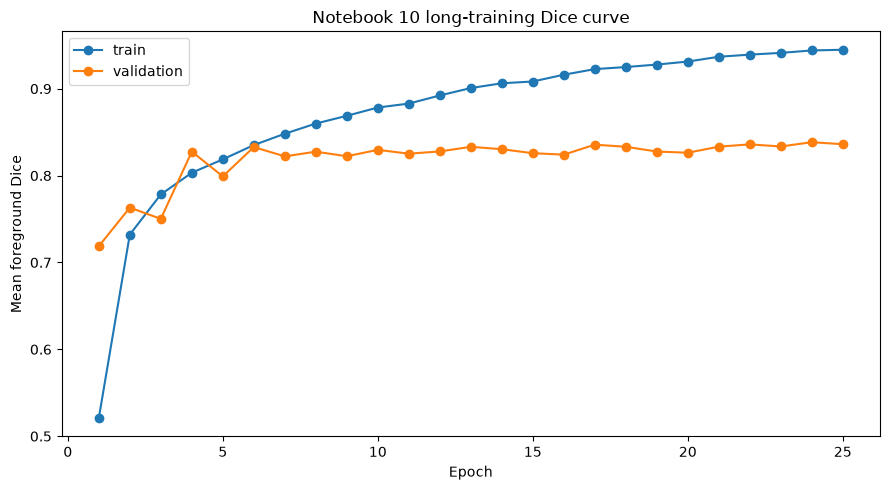

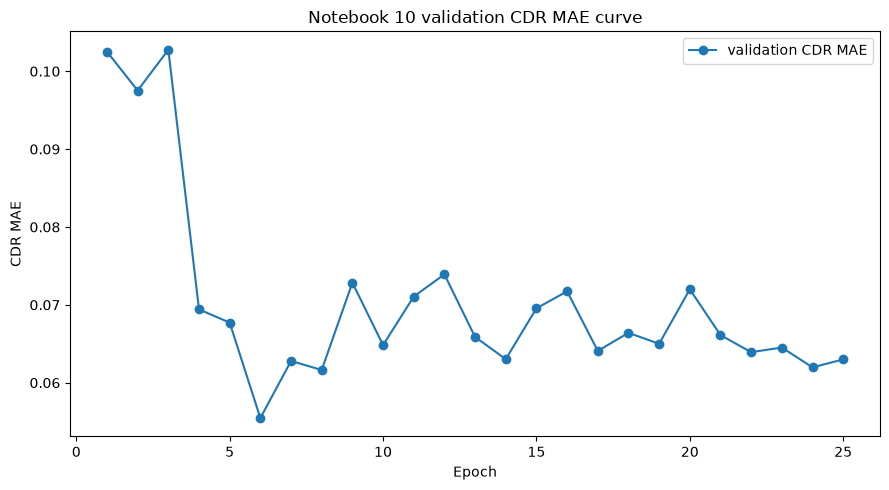

,epoch,loss,disc_dice,cup_dice,mean_foreground_dice,cdr_mae
47,24,0.126366,0.860335,0.816529,0.838432,0.061972
49,25,0.128488,0.866347,0.805903,0.836125,0.062989
43,22,0.126427,0.864094,0.807755,0.835924,0.063919
33,17,0.121750,0.861246,0.809955,0.835600,0.064086
45,23,0.128561,0.853773,0.813311,0.833542,0.064518
41,21,0.124338,0.857774,0.808834,0.833304,0.066115
35,18,0.123598,0.860847,0.805548,0.833198,0.066403
25,13,0.120656,0.855050,0.811241,0.833145,0.065876
11,6,0.125965,0.852499,0.813224,0.832861,0.055457
27,14,0.125969,0.860109,0.800615,0.830362,0.063023


In [15]:
# 10.15 — Training curve visualization

history = pd.read_csv(HISTORY_PATH)

plot_frame = history.copy()
plot_frame["mean_foreground_dice"] = (plot_frame["disc_dice"] + plot_frame["cup_dice"]) / 2.0

val_frame = plot_frame.loc[plot_frame["phase"] == "val"].copy()
train_frame = plot_frame.loc[plot_frame["phase"] == "train"].copy()

plt.figure(figsize=(9, 5))
plt.plot(train_frame["epoch"], train_frame["mean_foreground_dice"], marker="o", label="train")
plt.plot(val_frame["epoch"], val_frame["mean_foreground_dice"], marker="o", label="validation")
plt.xlabel("Epoch")
plt.ylabel("Mean foreground Dice")
plt.title("Notebook 10 long-training Dice curve")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 5))
plt.plot(val_frame["epoch"], val_frame["cdr_mae"], marker="o", label="validation CDR MAE")
plt.xlabel("Epoch")
plt.ylabel("CDR MAE")
plt.title("Notebook 10 validation CDR MAE curve")
plt.legend()
plt.tight_layout()
plt.show()

display(
    val_frame[
        [
            "epoch",
            "loss",
            "disc_dice",
            "cup_dice",
            "mean_foreground_dice",
            "cdr_mae",
        ]
    ].sort_values("mean_foreground_dice", ascending=False).head(10)
)


## 10.16 — Handoff summary

Notebook 10 produces the long-trained public-data model that will be carried into Notebook 11 for clinical generalization evaluation.

The private checkpoint path is intentionally under `data/interim/` and should not be committed. Notebook 11 should load this private checkpoint if it is available locally. If the private checkpoint is missing, Notebook 11 should stop and ask whether Notebook 10 should be rerun rather than silently rebuilding the model.

In [16]:
# 10.16 — Final handoff summary

summary = pd.read_csv(SUMMARY_PATH).iloc[0].to_dict()

handoff = {
    "notebook": "10_long_training_selected_public_model",
    "clinical_data_used": False,
    "selected_notebook_09_strategy": summary["strategy_name"],
    "component_strategies": summary["component_strategies"],
    "epochs_requested": summary["epochs_requested"],
    "best_epoch_by_val_mean_foreground_dice": summary["best_epoch_by_val_mean_foreground_dice"],
    "best_val_mean_foreground_dice": summary["best_val_mean_foreground_dice"],
    "public_test_mean_foreground_dice": summary["test_mean_foreground_dice"],
    "public_test_disc_dice": summary["test_disc_dice"],
    "public_test_cup_dice": summary["test_cup_dice"],
    "public_test_cdr_mae": summary["test_cdr_mae"],
    "delta_vs_notebook_07_test_mean_foreground_dice": summary[
        "delta_vs_notebook_07_test_mean_foreground_dice"
    ],
    "meaningful_improvement_vs_notebook_07_test": bool(
        summary["meaningful_improvement_vs_notebook_07_test"]
    ),
    "private_checkpoint_saved": bool(summary["private_best_checkpoint_saved"]),
    "private_checkpoint_path": summary["private_best_checkpoint_path"],
    "next_notebook": "11_long_training_clinical_generalization.ipynb",
    "next_step": (
        "Load the private Notebook 10 best checkpoint, evaluate it on the same "
        "clinical PSD-derived subset used in Notebook 08, and compare pure "
        "clinical generalization against Notebook 08."
    ),
}

display(pd.DataFrame([handoff]).T.rename(columns={0: "value"}))


,value
notebook,10_long_training_selected_public_model
clinical_data_used,False
selected_notebook_09_strategy,combo_affine_vignette_blur
component_strategies,small_affine;vignette_illumination;defocus_blur
epochs_requested,25
best_epoch_by_val_mean_foreground_dice,24
best_val_mean_foreground_dice,0.838432
public_test_mean_foreground_dice,0.842136
public_test_disc_dice,0.864347
public_test_cup_dice,0.819926
